In [1]:
# Parameters
run_id = "ff65ae5c-f636-4122-9894-971278e5e4d2"
artifacts_dir = "/home/adnoman/projects/aml_gan/AMLend2end/artifacts/runs/ff65ae5c-f636-4122-9894-971278e5e4d2"
sample_size = None
epochs = None
threshold = None


# AML Pattern Analysis & Rule Extraction

This notebook analyzes **WHY** transactions are flagged as suspicious and extracts:
1. **Amount Patterns** - Transaction value thresholds and distributions
2. **Timing Patterns** - Frequency, velocity of transactions
3. **Network Patterns** - Structural characteristics (fan-out, fan-in, cycles)
4. **Behavioral Rules** - Extracted rules for AML detection
5. **Feature Importance** - What drives anomaly scores

In [2]:
# Setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import networkx as nx
from tensorflow import keras
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_PATH = os.path.dirname(os.path.abspath("__file__"))
TRAINING_DATA_PATH = os.path.join(BASE_PATH, "training_data")
OUTPUT_PATH = os.path.join(BASE_PATH, "output")
MODELS_PATH = os.path.join(BASE_PATH, "models")

plt.style.use('default')
plt.rcParams['figure.figsize'] = [14, 8]
print("Setup complete!")

2026-02-02 16:54:19.775058: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 16:54:19.811463: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Setup complete!


2026-02-02 16:54:20.697147: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# Load all data
edges_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "edges_td.csv"))
nodes_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "node_td.csv"))
node_embeddings = pd.read_parquet(os.path.join(OUTPUT_PATH, "node_embeddings_fg.parquet"))

# Load model and compute anomaly scores
model_dirs = [d for d in os.listdir(MODELS_PATH) if d.startswith('gan_anomaly_')]
latest_model_dir = os.path.join(MODELS_PATH, sorted(model_dirs)[-1])
model = keras.models.load_model(os.path.join(latest_model_dir, "anomaly_detector.keras"))
threshold = np.load(os.path.join(latest_model_dir, "threshold.npy"))

# Compute anomaly scores
emb_cols = [c for c in node_embeddings.columns if c.startswith('emb_')]
all_embeddings = node_embeddings[emb_cols].values
reconstructed = model.predict(all_embeddings, verbose=0)
node_embeddings['anomaly_score'] = np.mean(np.square(all_embeddings - reconstructed), axis=1)
node_embeddings['is_anomaly'] = node_embeddings['anomaly_score'] > threshold

print(f"Loaded {len(edges_df):,} transactions, {len(nodes_df):,} nodes")
print(f"Anomalies: {node_embeddings['is_anomaly'].sum():,} ({100*node_embeddings['is_anomaly'].mean():.1f}%)")

I0000 00:00:1770033261.175462  120193 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


2026-02-02 16:54:22.011907: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e95fc002dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 16:54:22.011938: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-02-02 16:54:22.016758: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-02 16:54:22.038979: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


I0000 00:00:1770033262.473582  120432 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Loaded 438,386 transactions, 7,347 nodes
Anomalies: 7,304 (99.4%)


In [4]:
# Build comprehensive node features
G = nx.from_pandas_edgelist(edges_df, 'source', 'target', edge_attr='base_amt', create_using=nx.DiGraph())

# Calculate network metrics for each node
node_features = node_embeddings[['id', 'anomaly_score', 'is_anomaly']].copy()
if 'is_sar' in node_embeddings.columns:
    node_features['is_sar'] = node_embeddings['is_sar']

# Degree metrics
node_features['in_degree'] = node_features['id'].map(dict(G.in_degree())).fillna(0)
node_features['out_degree'] = node_features['id'].map(dict(G.out_degree())).fillna(0)
node_features['total_degree'] = node_features['in_degree'] + node_features['out_degree']

# Transaction amounts
out_amounts = edges_df.groupby('source')['base_amt'].agg(['sum', 'mean', 'std', 'min', 'max', 'count'])
out_amounts.columns = ['out_total', 'out_mean', 'out_std', 'out_min', 'out_max', 'out_count']
in_amounts = edges_df.groupby('target')['base_amt'].agg(['sum', 'mean', 'std', 'min', 'max', 'count'])
in_amounts.columns = ['in_total', 'in_mean', 'in_std', 'in_min', 'in_max', 'in_count']

node_features = node_features.merge(out_amounts, left_on='id', right_index=True, how='left')
node_features = node_features.merge(in_amounts, left_on='id', right_index=True, how='left')
node_features = node_features.fillna(0)

# Derived features
node_features['total_volume'] = node_features['out_total'] + node_features['in_total']
node_features['net_flow'] = node_features['in_total'] - node_features['out_total']
node_features['flow_ratio'] = node_features['out_total'] / (node_features['in_total'] + 1)  # Avoid div by 0
node_features['avg_txn_size'] = node_features['total_volume'] / (node_features['total_degree'] + 1)
node_features['txn_std'] = (node_features['out_std'].fillna(0) + node_features['in_std'].fillna(0)) / 2

# Unique counterparties
unique_targets = edges_df.groupby('source')['target'].nunique().rename('unique_targets')
unique_sources = edges_df.groupby('target')['source'].nunique().rename('unique_sources')
node_features = node_features.merge(unique_targets, left_on='id', right_index=True, how='left')
node_features = node_features.merge(unique_sources, left_on='id', right_index=True, how='left')
node_features['unique_counterparties'] = node_features['unique_targets'].fillna(0) + node_features['unique_sources'].fillna(0)

# Fan-out ratio (many targets from one source = potential structuring)
node_features['fan_out_ratio'] = node_features['unique_targets'].fillna(0) / (node_features['out_count'] + 1)
node_features['fan_in_ratio'] = node_features['unique_sources'].fillna(0) / (node_features['in_count'] + 1)

print(f"Created {len(node_features.columns)} features for {len(node_features)} nodes")
node_features.head()

Created 29 features for 7347 nodes


,id,anomaly_score,is_anomaly,is_sar,in_degree,out_degree,total_degree,out_total,out_mean,out_std,...,total_volume,net_flow,flow_ratio,avg_txn_size,txn_std,unique_targets,unique_sources,unique_counterparties,fan_out_ratio,fan_in_ratio
0,3aa9646b,0.000325,True,0,1,4,5,45885.98,559.585122,269.278552,...,56127.55,-35644.41,4.479928,9354.591667,261.949060,4.0,1.0,5.0,0.048193,0.045455
1,1e46e726,0.000335,True,0,1,2,3,27971.54,537.914231,254.855897,...,39991.47,-15951.61,2.326903,9997.867500,264.816115,2.0,1.0,3.0,0.037736,0.045455
2,49203bc3,0.000300,True,0,0,1,1,64403.24,536.693667,254.112505,...,64403.24,-64403.24,64403.240000,32201.620000,127.056253,1.0,NaN,1.0,0.008264,0.000000
3,a74d1101,0.000213,True,1,1,1,2,2775.71,2775.710000,0.000000,...,67178.95,61627.53,0.043098,22392.983333,127.056253,1.0,1.0,2.0,0.500000,0.008264
4,616d4505,0.000204,True,0,3,3,6,41687.73,555.836400,257.826182,...,75310.70,-8064.76,1.239822,10758.671429,250.303788,3.0,3.0,6.0,0.039474,0.052632


---
# 1. AMOUNT PATTERNS
---

In [5]:
# Compare amount statistics: Suspicious vs Normal
suspicious = node_features[node_features['is_anomaly'] == True]
normal = node_features[node_features['is_anomaly'] == False]

amount_features = ['total_volume', 'avg_txn_size', 'out_mean', 'in_mean', 'out_max', 'in_max', 'txn_std']

print("="*80)
print(" AMOUNT PATTERN ANALYSIS: Suspicious vs Normal Nodes")
print("="*80)
print(f"\n{'Feature':<25} {'Suspicious Mean':>18} {'Normal Mean':>18} {'Ratio':>10} {'P-value':>12}")
print("-"*80)

amount_rules = []
for feat in amount_features:
    susp_mean = suspicious[feat].mean()
    norm_mean = normal[feat].mean() if len(normal) > 0 else 0
    ratio = susp_mean / (norm_mean + 0.001)
    
    # Statistical test
    if len(normal) > 0 and len(suspicious) > 0:
        _, p_value = stats.mannwhitneyu(suspicious[feat], normal[feat], alternative='two-sided')
    else:
        p_value = 1.0
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{feat:<25} ${susp_mean:>17,.2f} ${norm_mean:>17,.2f} {ratio:>9.2f}x {p_value:>10.4f} {significance}")
    
    if p_value < 0.05:
        direction = "higher" if ratio > 1 else "lower"
        amount_rules.append(f"Suspicious nodes have {ratio:.1f}x {direction} {feat.replace('_', ' ')}")

print("\n*** p<0.001, ** p<0.01, * p<0.05")

 AMOUNT PATTERN ANALYSIS: Suspicious vs Normal Nodes

Feature                      Suspicious Mean        Normal Mean      Ratio      P-value
--------------------------------------------------------------------------------
total_volume              $        66,035.53 $        59,220.40      1.12x     0.3901 
avg_txn_size              $        12,342.85 $        10,673.88      1.16x     0.1174 
out_mean                  $           486.06 $           568.98      0.85x     0.4345 
in_mean                   $           503.60 $           464.96      1.08x     0.0495 *
out_max                   $           913.11 $         1,029.95      0.89x     0.0812 
in_max                    $           973.91 $           767.95      1.27x     0.0109 *
txn_std                   $           231.19 $           216.30      1.07x     0.3454 

*** p<0.001, ** p<0.01, * p<0.05


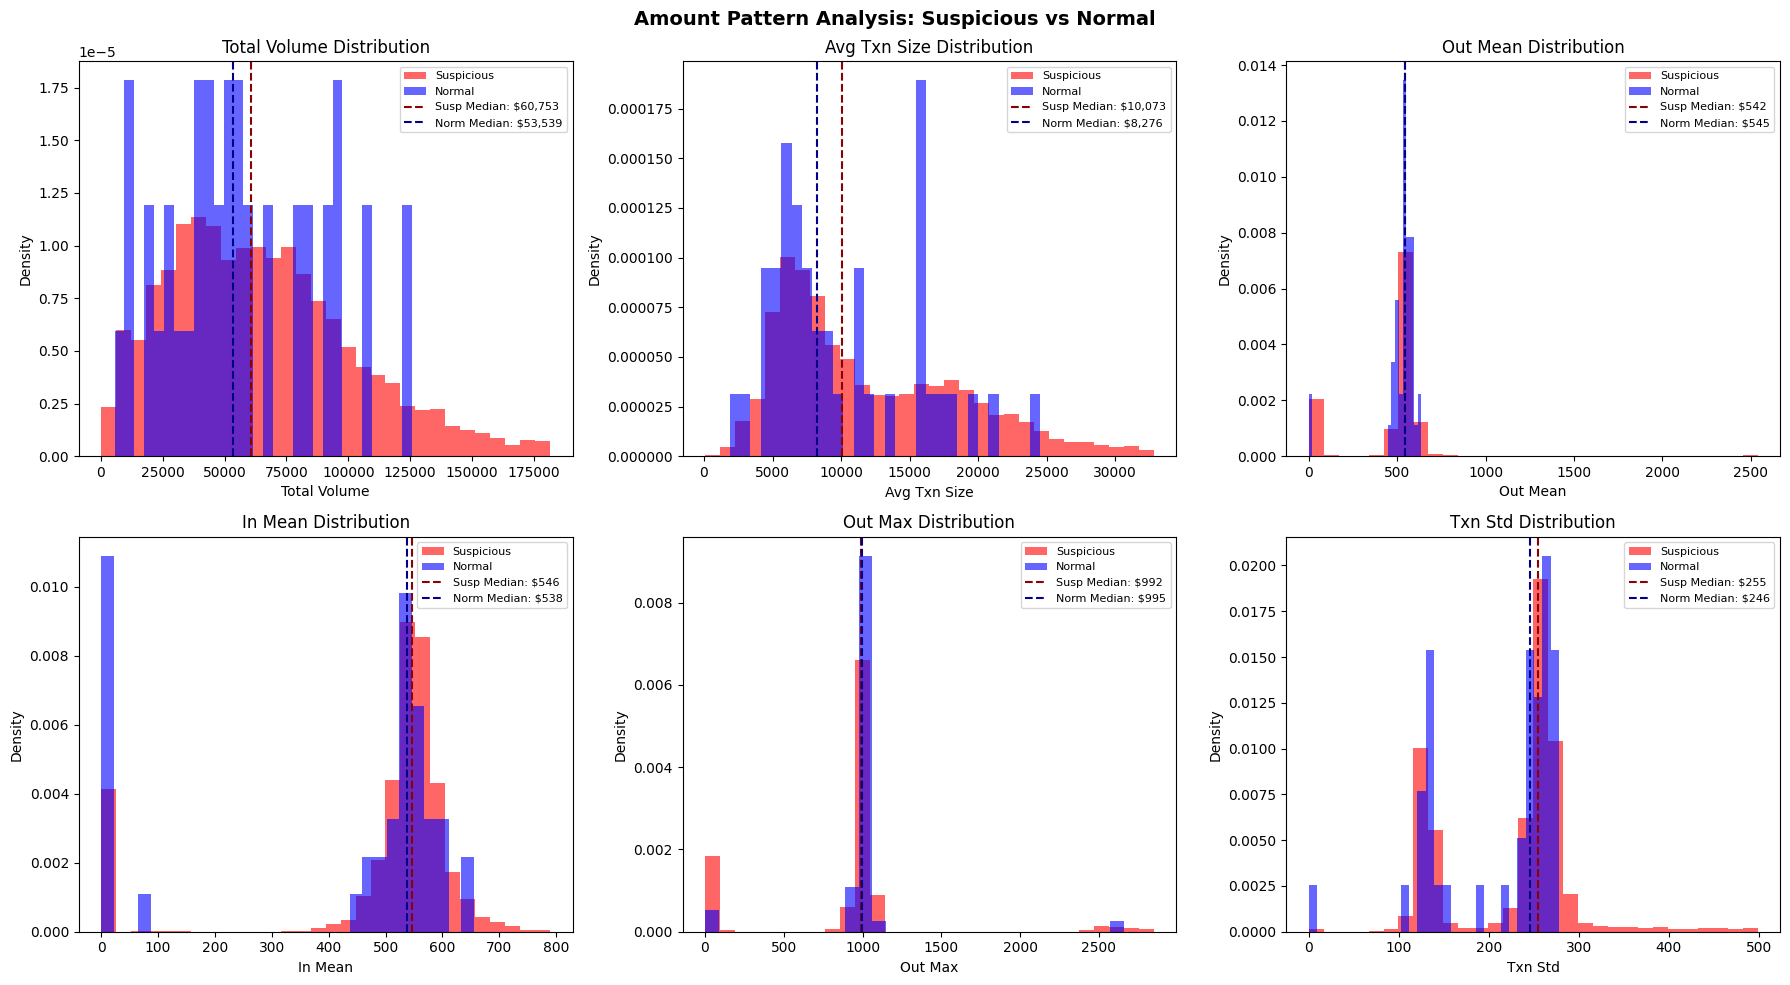

In [6]:
# Visualize amount distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(['total_volume', 'avg_txn_size', 'out_mean', 'in_mean', 'out_max', 'txn_std']):
    ax = axes[idx // 3, idx % 3]
    
    # Remove outliers for visualization
    susp_data = suspicious[feat]
    norm_data = normal[feat]
    
    susp_q99 = susp_data.quantile(0.99)
    norm_q99 = norm_data.quantile(0.99) if len(norm_data) > 0 else susp_q99
    
    ax.hist(susp_data[susp_data <= susp_q99], bins=30, alpha=0.6, label='Suspicious', color='red', density=True)
    if len(norm_data) > 0:
        ax.hist(norm_data[norm_data <= norm_q99], bins=30, alpha=0.6, label='Normal', color='blue', density=True)
    
    ax.axvline(susp_data.median(), color='darkred', linestyle='--', label=f'Susp Median: ${susp_data.median():,.0f}')
    if len(norm_data) > 0:
        ax.axvline(norm_data.median(), color='darkblue', linestyle='--', label=f'Norm Median: ${norm_data.median():,.0f}')
    
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.set_title(f'{feat.replace("_", " ").title()} Distribution')
    ax.legend(fontsize=8)

plt.suptitle('Amount Pattern Analysis: Suspicious vs Normal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pattern_amounts.png'), dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Extract amount-based rules
print("\n" + "="*60)
print(" EXTRACTED AMOUNT RULES")
print("="*60)

# Calculate thresholds (using percentiles)
rules = []

# Rule 1: High transaction volume
vol_threshold = node_features['total_volume'].quantile(0.90)
high_vol_susp_rate = node_features[node_features['total_volume'] > vol_threshold]['is_anomaly'].mean()
rules.append({
    'rule': f"Total volume > ${vol_threshold:,.0f}",
    'suspicious_rate': high_vol_susp_rate,
    'description': 'High total transaction volume'
})

# Rule 2: Large average transaction
avg_threshold = node_features['avg_txn_size'].quantile(0.90)
high_avg_susp_rate = node_features[node_features['avg_txn_size'] > avg_threshold]['is_anomaly'].mean()
rules.append({
    'rule': f"Avg transaction > ${avg_threshold:,.0f}",
    'suspicious_rate': high_avg_susp_rate,
    'description': 'Large average transaction size'
})

# Rule 3: High variance in transaction amounts
std_threshold = node_features['txn_std'].quantile(0.90)
high_std_susp_rate = node_features[node_features['txn_std'] > std_threshold]['is_anomaly'].mean()
rules.append({
    'rule': f"Transaction std > ${std_threshold:,.0f}",
    'suspicious_rate': high_std_susp_rate,
    'description': 'High variance in amounts (inconsistent behavior)'
})

# Rule 4: Max transaction spike
max_threshold = node_features['out_max'].quantile(0.95)
high_max_susp_rate = node_features[node_features['out_max'] > max_threshold]['is_anomaly'].mean()
rules.append({
    'rule': f"Max outgoing > ${max_threshold:,.0f}",
    'suspicious_rate': high_max_susp_rate,
    'description': 'Very large single outgoing transaction'
})

for i, r in enumerate(rules, 1):
    print(f"\nRule {i}: {r['rule']}")
    print(f"   Suspicious Rate: {100*r['suspicious_rate']:.1f}%")
    print(f"   Interpretation: {r['description']}")


 EXTRACTED AMOUNT RULES

Rule 1: Total volume > $118,351
   Suspicious Rate: 99.6%
   Interpretation: High total transaction volume

Rule 2: Avg transaction > $22,363
   Suspicious Rate: 99.7%
   Interpretation: Large average transaction size

Rule 3: Transaction std > $281
   Suspicious Rate: 99.9%
   Interpretation: High variance in amounts (inconsistent behavior)

Rule 4: Max outgoing > $2,479
   Suspicious Rate: 99.4%
   Interpretation: Very large single outgoing transaction


---
# 2. NETWORK/STRUCTURAL PATTERNS
---

In [8]:
# Analyze network structure patterns
network_features = ['in_degree', 'out_degree', 'total_degree', 'unique_counterparties', 'fan_out_ratio', 'fan_in_ratio']

print("="*80)
print(" NETWORK PATTERN ANALYSIS: Suspicious vs Normal Nodes")
print("="*80)
print(f"\n{'Feature':<25} {'Suspicious Mean':>18} {'Normal Mean':>18} {'Ratio':>10} {'P-value':>12}")
print("-"*80)

network_rules = []
for feat in network_features:
    susp_mean = suspicious[feat].mean()
    norm_mean = normal[feat].mean() if len(normal) > 0 else 0
    ratio = susp_mean / (norm_mean + 0.001)
    
    if len(normal) > 0 and len(suspicious) > 0:
        _, p_value = stats.mannwhitneyu(suspicious[feat], normal[feat], alternative='two-sided')
    else:
        p_value = 1.0
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{feat:<25} {susp_mean:>18.2f} {norm_mean:>18.2f} {ratio:>9.2f}x {p_value:>10.4f} {significance}")
    
    if p_value < 0.05:
        direction = "higher" if ratio > 1 else "lower"
        network_rules.append(f"Suspicious nodes have {ratio:.1f}x {direction} {feat.replace('_', ' ')}")

 NETWORK PATTERN ANALYSIS: Suspicious vs Normal Nodes

Feature                      Suspicious Mean        Normal Mean      Ratio      P-value
--------------------------------------------------------------------------------
in_degree                               2.33               1.93      1.20x     0.0877 
out_degree                              2.32               2.98      0.78x     0.0072 **
total_degree                            4.65               4.91      0.95x     0.4276 
unique_counterparties                   4.65               4.91      0.95x     0.4276 
fan_out_ratio                           0.05               0.06      0.84x     0.0353 *
fan_in_ratio                            0.05               0.07      0.70x     0.2947 


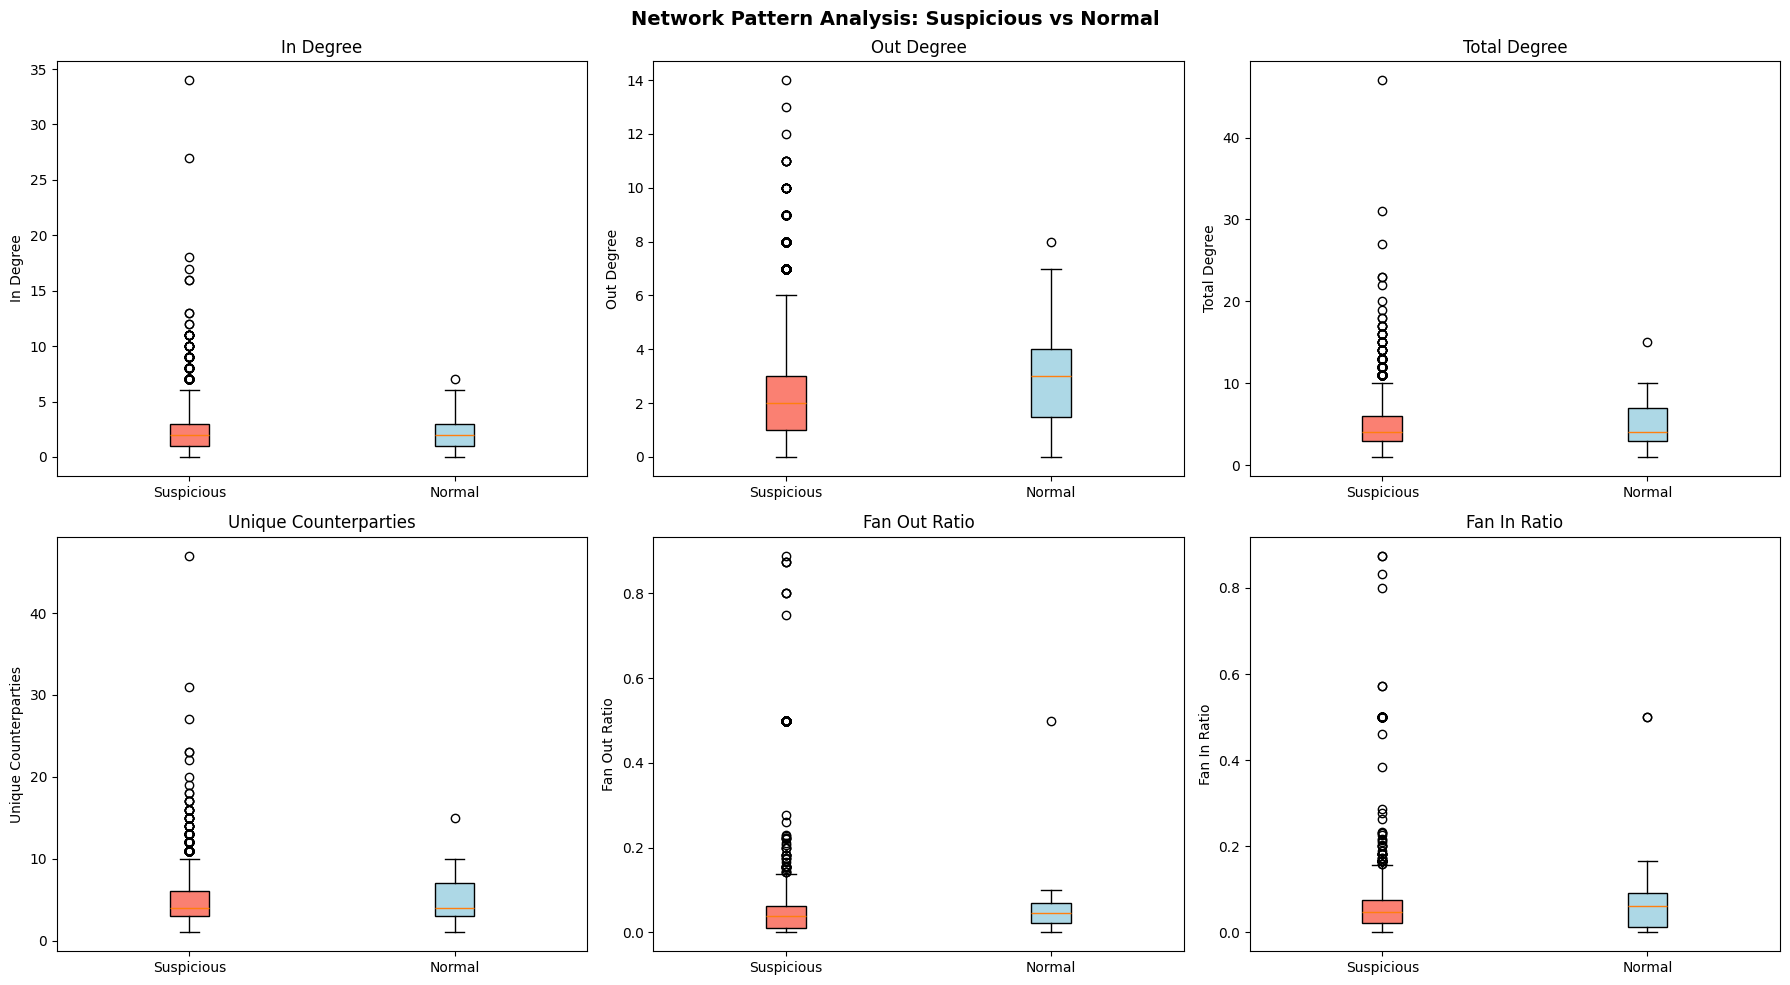

In [9]:
# Visualize network patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(network_features):
    ax = axes[idx // 3, idx % 3]
    
    susp_data = suspicious[feat]
    norm_data = normal[feat]
    
    bp = ax.boxplot([susp_data, norm_data] if len(norm_data) > 0 else [susp_data], 
                    labels=['Suspicious', 'Normal'] if len(norm_data) > 0 else ['Suspicious'],
                    patch_artist=True)
    
    colors = ['salmon', 'lightblue'] if len(norm_data) > 0 else ['salmon']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel(feat.replace('_', ' ').title())
    ax.set_title(f'{feat.replace("_", " ").title()}')

plt.suptitle('Network Pattern Analysis: Suspicious vs Normal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pattern_network.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Extract network-based rules
print("\n" + "="*60)
print(" EXTRACTED NETWORK/STRUCTURAL RULES")
print("="*60)

network_rules_extracted = []

# Rule: High fan-out (structuring pattern)
fanout_threshold = node_features['unique_targets'].quantile(0.90)
if fanout_threshold > 0:
    high_fanout_rate = node_features[node_features['unique_targets'] > fanout_threshold]['is_anomaly'].mean()
    network_rules_extracted.append({
        'rule': f"Sends to > {fanout_threshold:.0f} unique recipients",
        'suspicious_rate': high_fanout_rate,
        'pattern': 'STRUCTURING / LAYERING',
        'description': 'Sending money to many different accounts (potential smurfing)'
    })

# Rule: High fan-in (collection pattern)
fanin_threshold = node_features['unique_sources'].quantile(0.90)
if fanin_threshold > 0:
    high_fanin_rate = node_features[node_features['unique_sources'] > fanin_threshold]['is_anomaly'].mean()
    network_rules_extracted.append({
        'rule': f"Receives from > {fanin_threshold:.0f} unique senders",
        'suspicious_rate': high_fanin_rate,
        'pattern': 'COLLECTION / AGGREGATION',
        'description': 'Receiving money from many sources (potential collection point)'
    })

# Rule: High total degree (hub)
degree_threshold = node_features['total_degree'].quantile(0.95)
high_degree_rate = node_features[node_features['total_degree'] > degree_threshold]['is_anomaly'].mean()
network_rules_extracted.append({
    'rule': f"Total connections > {degree_threshold:.0f}",
    'suspicious_rate': high_degree_rate,
    'pattern': 'HUB / CENTRAL NODE',
    'description': 'Highly connected node acting as money hub'
})

# Rule: Imbalanced flow (mostly outgoing or incoming)
node_features['flow_imbalance'] = abs(node_features['out_total'] - node_features['in_total']) / (node_features['total_volume'] + 1)
imbalance_threshold = 0.8
high_imbalance_rate = node_features[node_features['flow_imbalance'] > imbalance_threshold]['is_anomaly'].mean()
network_rules_extracted.append({
    'rule': f"Flow imbalance > {100*imbalance_threshold:.0f}%",
    'suspicious_rate': high_imbalance_rate,
    'pattern': 'ONE-WAY FLOW',
    'description': 'Mostly sending OR receiving (not balanced like normal accounts)'
})

for i, r in enumerate(network_rules_extracted, 1):
    print(f"\nRule {i}: {r['rule']}")
    print(f"   Pattern Type: {r['pattern']}")
    print(f"   Suspicious Rate: {100*r['suspicious_rate']:.1f}%")
    print(f"   Interpretation: {r['description']}")


 EXTRACTED NETWORK/STRUCTURAL RULES

Rule 1: Sends to > 6 unique recipients
   Pattern Type: STRUCTURING / LAYERING
   Suspicious Rate: 99.3%
   Interpretation: Sending money to many different accounts (potential smurfing)

Rule 2: Receives from > 5 unique senders
   Pattern Type: COLLECTION / AGGREGATION
   Suspicious Rate: 99.4%
   Interpretation: Receiving money from many sources (potential collection point)

Rule 3: Total connections > 10
   Pattern Type: HUB / CENTRAL NODE
   Suspicious Rate: 99.6%
   Interpretation: Highly connected node acting as money hub

Rule 4: Flow imbalance > 80%
   Pattern Type: ONE-WAY FLOW
   Suspicious Rate: 99.3%
   Interpretation: Mostly sending OR receiving (not balanced like normal accounts)


---
# 3. TRANSACTION FREQUENCY PATTERNS
---

In [11]:
# Analyze transaction frequency patterns
# Use transaction ID as proxy for time ordering

# Transactions per node
node_features['total_txns'] = node_features['out_count'] + node_features['in_count']

# Transactions to same counterparty (repetition)
repeat_txns = edges_df.groupby(['source', 'target']).size().reset_index(name='repeat_count')
avg_repeat_out = repeat_txns.groupby('source')['repeat_count'].mean().rename('avg_repeat_to_same')
max_repeat_out = repeat_txns.groupby('source')['repeat_count'].max().rename('max_repeat_to_same')

node_features = node_features.merge(avg_repeat_out, left_on='id', right_index=True, how='left')
node_features = node_features.merge(max_repeat_out, left_on='id', right_index=True, how='left')
node_features['avg_repeat_to_same'] = node_features['avg_repeat_to_same'].fillna(0)
node_features['max_repeat_to_same'] = node_features['max_repeat_to_same'].fillna(0)

# Transaction velocity (using tran_id range as proxy)
tran_velocity = edges_df.groupby('source')['tran_id'].agg(['min', 'max', 'count'])
tran_velocity['txn_spread'] = tran_velocity['max'] - tran_velocity['min']
tran_velocity['velocity'] = tran_velocity['count'] / (tran_velocity['txn_spread'] + 1)  # Txns per ID range
node_features = node_features.merge(tran_velocity[['velocity', 'txn_spread']], left_on='id', right_index=True, how='left')
node_features['velocity'] = node_features['velocity'].fillna(0)
node_features['txn_spread'] = node_features['txn_spread'].fillna(0)

In [12]:
# Analyze frequency patterns
frequency_features = ['total_txns', 'avg_repeat_to_same', 'max_repeat_to_same', 'velocity']

print("="*80)
print(" FREQUENCY/TIMING PATTERN ANALYSIS")
print("="*80)
print(f"\n{'Feature':<25} {'Suspicious Mean':>18} {'Normal Mean':>18} {'Ratio':>10}")
print("-"*80)

suspicious = node_features[node_features['is_anomaly'] == True]
normal = node_features[node_features['is_anomaly'] == False]

for feat in frequency_features:
    susp_mean = suspicious[feat].mean()
    norm_mean = normal[feat].mean() if len(normal) > 0 else 0
    ratio = susp_mean / (norm_mean + 0.001)
    print(f"{feat:<25} {susp_mean:>18.2f} {norm_mean:>18.2f} {ratio:>9.2f}x")

 FREQUENCY/TIMING PATTERN ANALYSIS

Feature                      Suspicious Mean        Normal Mean      Ratio
--------------------------------------------------------------------------------
total_txns                            119.41             107.28      1.11x
avg_repeat_to_same                     29.92              28.15      1.06x
max_repeat_to_same                     37.95              38.65      0.98x
velocity                                0.02               0.02      0.82x


In [13]:
# Extract frequency rules
print("\n" + "="*60)
print(" EXTRACTED FREQUENCY/TIMING RULES")
print("="*60)

frequency_rules = []

# High transaction count
txn_threshold = node_features['total_txns'].quantile(0.90)
high_txn_rate = node_features[node_features['total_txns'] > txn_threshold]['is_anomaly'].mean()
frequency_rules.append({
    'rule': f"Total transactions > {txn_threshold:.0f}",
    'suspicious_rate': high_txn_rate,
    'pattern': 'HIGH ACTIVITY',
    'description': 'Unusually high number of transactions'
})

# Repeated transactions to same target
repeat_threshold = node_features['max_repeat_to_same'].quantile(0.90)
if repeat_threshold > 1:
    high_repeat_rate = node_features[node_features['max_repeat_to_same'] > repeat_threshold]['is_anomaly'].mean()
    frequency_rules.append({
        'rule': f"Repeated txns to same target > {repeat_threshold:.0f}",
        'suspicious_rate': high_repeat_rate,
        'pattern': 'REPETITIVE BEHAVIOR',
        'description': 'Multiple transactions to same recipient (potential structuring)'
    })

# High velocity
vel_threshold = node_features['velocity'].quantile(0.90)
if vel_threshold > 0:
    high_vel_rate = node_features[node_features['velocity'] > vel_threshold]['is_anomaly'].mean()
    frequency_rules.append({
        'rule': f"Transaction velocity > {vel_threshold:.4f}",
        'suspicious_rate': high_vel_rate,
        'pattern': 'RAPID TRANSACTIONS',
        'description': 'High frequency of transactions in short period'
    })

for i, r in enumerate(frequency_rules, 1):
    print(f"\nRule {i}: {r['rule']}")
    print(f"   Pattern Type: {r['pattern']}")
    print(f"   Suspicious Rate: {100*r['suspicious_rate']:.1f}%")
    print(f"   Interpretation: {r['description']}")


 EXTRACTED FREQUENCY/TIMING RULES

Rule 1: Total transactions > 215
   Pattern Type: HIGH ACTIVITY
   Suspicious Rate: 99.6%
   Interpretation: Unusually high number of transactions

Rule 2: Repeated txns to same target > 103
   Pattern Type: REPETITIVE BEHAVIOR
   Suspicious Rate: 99.1%
   Interpretation: Multiple transactions to same recipient (potential structuring)

Rule 3: Transaction velocity > 0.0001
   Pattern Type: RAPID TRANSACTIONS
   Suspicious Rate: 99.2%
   Interpretation: High frequency of transactions in short period


---
# 4. FEATURE IMPORTANCE (What Drives Anomaly Scores)
---

In [14]:
# Calculate correlation between features and anomaly score
feature_cols = ['total_volume', 'avg_txn_size', 'out_mean', 'in_mean', 'txn_std',
                'in_degree', 'out_degree', 'total_degree', 'unique_counterparties',
                'fan_out_ratio', 'fan_in_ratio', 'flow_imbalance', 'net_flow',
                'total_txns', 'velocity', 'avg_repeat_to_same']

correlations = []
for feat in feature_cols:
    if feat in node_features.columns:
        corr = node_features[feat].corr(node_features['anomaly_score'])
        correlations.append({'feature': feat, 'correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)

print("="*60)
print(" FEATURE IMPORTANCE (Correlation with Anomaly Score)")
print("="*60)
print(corr_df.to_string(index=False))

 FEATURE IMPORTANCE (Correlation with Anomaly Score)
              feature  correlation
             net_flow     0.029315
         avg_txn_size     0.028162
         total_volume     0.027581
           total_txns     0.027172
            in_degree     0.021375
             out_mean     0.018022
             velocity     0.013467
   avg_repeat_to_same     0.008354
         total_degree     0.006864
unique_counterparties     0.006864
        fan_out_ratio     0.005943
              in_mean     0.001536
              txn_std    -0.005265
           out_degree    -0.009519
       flow_imbalance    -0.016543
         fan_in_ratio    -0.025341


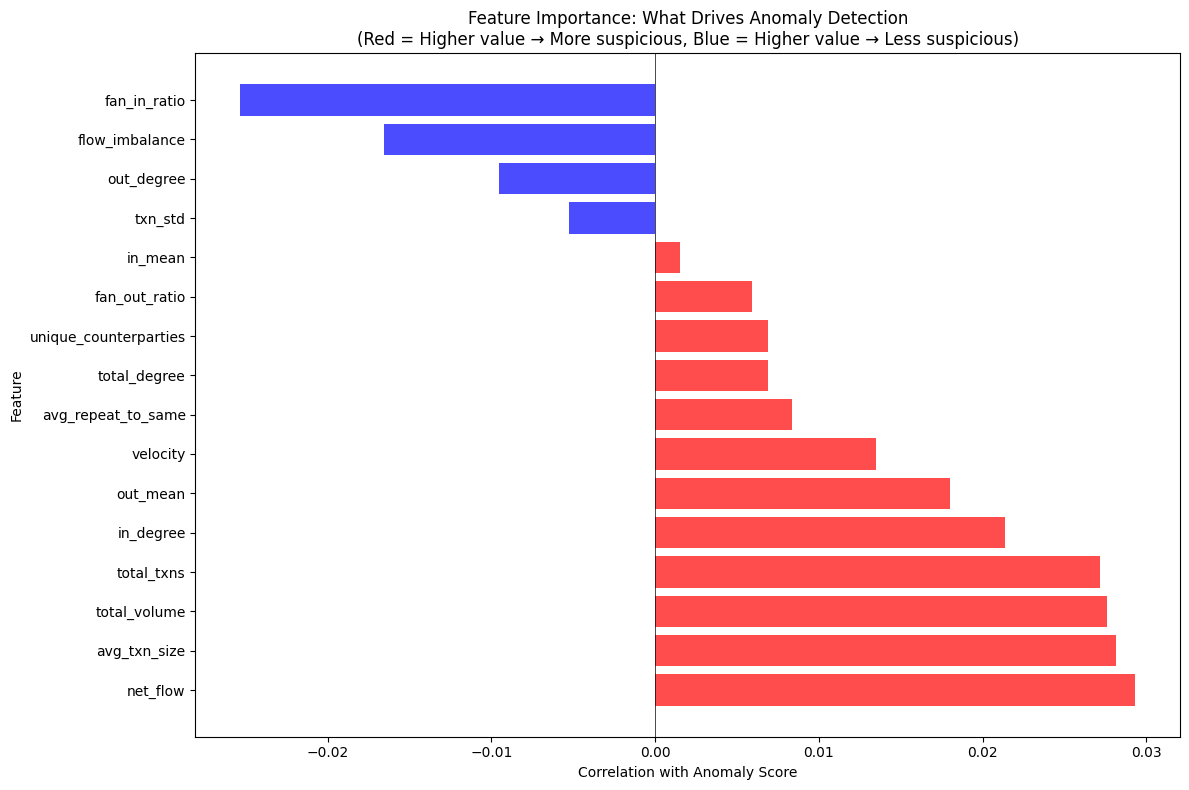

In [15]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['red' if c > 0 else 'blue' for c in corr_df['correlation']]
bars = ax.barh(corr_df['feature'], corr_df['correlation'], color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with Anomaly Score')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance: What Drives Anomaly Detection\n(Red = Higher value → More suspicious, Blue = Higher value → Less suspicious)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pattern_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# 5. COMBINED RULE SUMMARY
---

In [16]:
# Final summary of all extracted patterns and rules
print("\n" + "="*80)
print(" AML PATTERN ANALYSIS - COMPLETE RULE SUMMARY")
print("="*80)

all_rules = []

# Combine all rules
for r in rules:
    all_rules.append({**r, 'category': 'AMOUNT'})
for r in network_rules_extracted:
    all_rules.append({**r, 'category': 'NETWORK'})
for r in frequency_rules:
    all_rules.append({**r, 'category': 'FREQUENCY'})

# Sort by suspicious rate
all_rules_sorted = sorted(all_rules, key=lambda x: x['suspicious_rate'], reverse=True)

print("\n" + "-"*80)
print(" TOP AML DETECTION RULES (Ranked by Suspicious Rate)")
print("-"*80)

for i, r in enumerate(all_rules_sorted, 1):
    pattern = r.get('pattern', r.get('description', 'N/A'))
    print(f"\n{i}. [{r['category']}] {r['rule']}")
    print(f"   Pattern: {pattern}")
    print(f"   Suspicious Rate: {100*r['suspicious_rate']:.1f}%")


 AML PATTERN ANALYSIS - COMPLETE RULE SUMMARY

--------------------------------------------------------------------------------
 TOP AML DETECTION RULES (Ranked by Suspicious Rate)
--------------------------------------------------------------------------------

1. [AMOUNT] Transaction std > $281
   Pattern: High variance in amounts (inconsistent behavior)
   Suspicious Rate: 99.9%

2. [AMOUNT] Avg transaction > $22,363
   Pattern: Large average transaction size
   Suspicious Rate: 99.7%

3. [AMOUNT] Total volume > $118,351
   Pattern: High total transaction volume
   Suspicious Rate: 99.6%

4. [FREQUENCY] Total transactions > 215
   Pattern: HIGH ACTIVITY
   Suspicious Rate: 99.6%

5. [NETWORK] Total connections > 10
   Pattern: HUB / CENTRAL NODE
   Suspicious Rate: 99.6%

6. [AMOUNT] Max outgoing > $2,479
   Pattern: Very large single outgoing transaction
   Suspicious Rate: 99.4%

7. [NETWORK] Receives from > 5 unique senders
   Pattern: COLLECTION / AGGREGATION
   Suspicious Rate

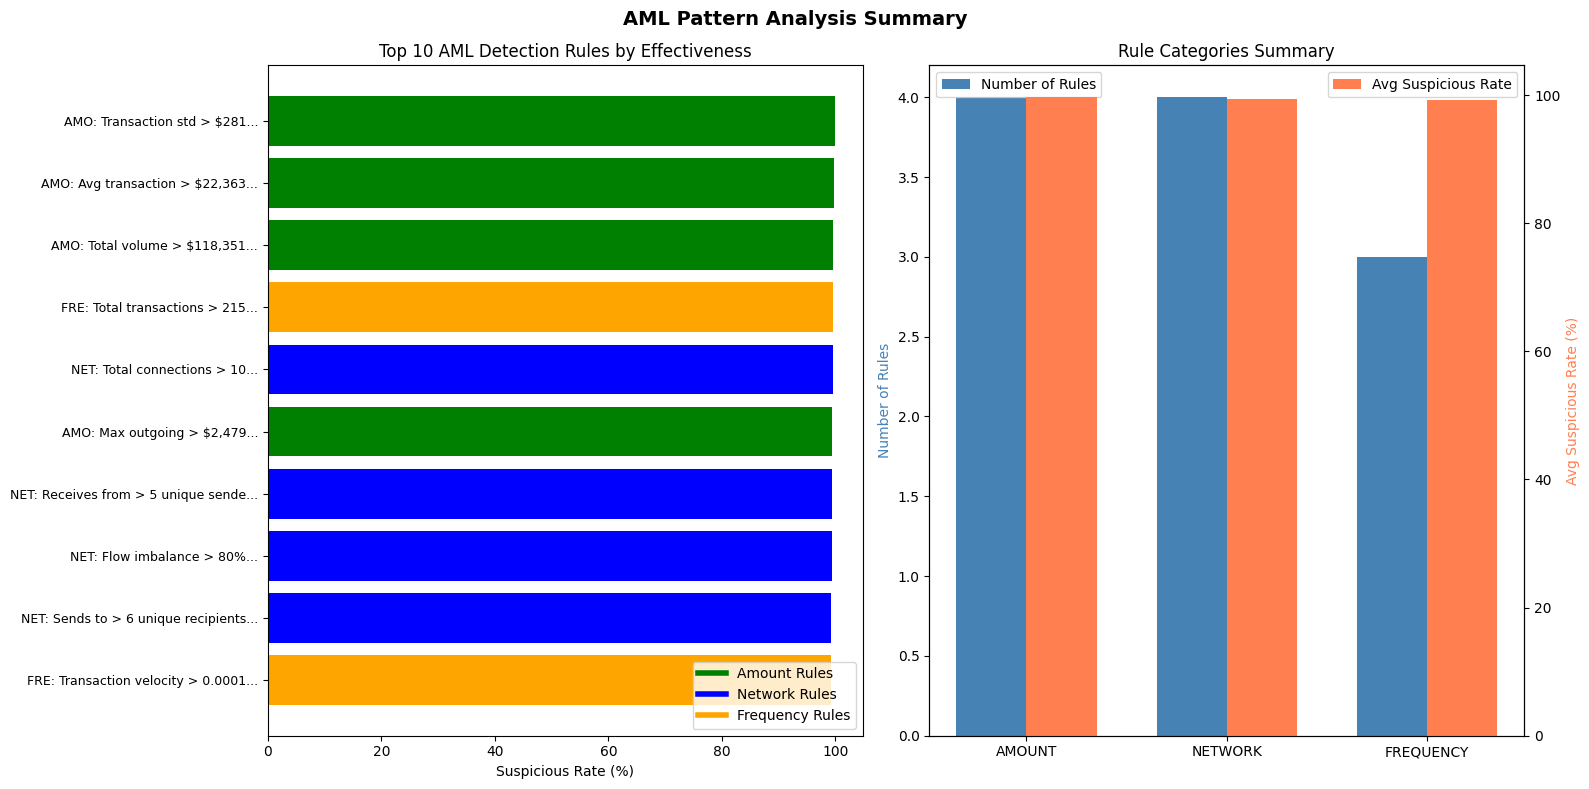

In [17]:
# Create a visual summary
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Rule effectiveness
ax1 = axes[0]
rule_names = [f"{r['category'][:3]}: {r['rule'][:30]}..." for r in all_rules_sorted[:10]]
rule_rates = [r['suspicious_rate'] * 100 for r in all_rules_sorted[:10]]
colors = {'AMO': 'green', 'NET': 'blue', 'FRE': 'orange'}
bar_colors = [colors.get(r['category'][:3], 'gray') for r in all_rules_sorted[:10]]

bars = ax1.barh(range(len(rule_names)), rule_rates, color=bar_colors)
ax1.set_yticks(range(len(rule_names)))
ax1.set_yticklabels(rule_names, fontsize=9)
ax1.set_xlabel('Suspicious Rate (%)')
ax1.set_title('Top 10 AML Detection Rules by Effectiveness')
ax1.invert_yaxis()

# Add legend
legend_elements = [
    Line2D([0], [0], color='green', lw=4, label='Amount Rules'),
    Line2D([0], [0], color='blue', lw=4, label='Network Rules'),
    Line2D([0], [0], color='orange', lw=4, label='Frequency Rules')
]
ax1.legend(handles=legend_elements, loc='lower right')

# Right: Pattern categories
ax2 = axes[1]
categories = ['AMOUNT', 'NETWORK', 'FREQUENCY']
cat_counts = [len([r for r in all_rules if r['category'] == c]) for c in categories]
cat_avg_rate = [np.mean([r['suspicious_rate'] for r in all_rules if r['category'] == c]) * 100 for c in categories]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, cat_counts, width, label='Number of Rules', color='steelblue')
ax2_twin = ax2.twinx()
ax2_twin.bar(x + width/2, cat_avg_rate, width, label='Avg Suspicious Rate', color='coral')

ax2.set_ylabel('Number of Rules', color='steelblue')
ax2_twin.set_ylabel('Avg Suspicious Rate (%)', color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_title('Rule Categories Summary')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.suptitle('AML Pattern Analysis Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pattern_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save rules to JSON
rules_output = {
    'generated_date': pd.Timestamp.now().isoformat(),
    'total_nodes_analyzed': len(node_features),
    'anomalies_detected': int(node_features['is_anomaly'].sum()),
    'anomaly_threshold': float(threshold),
    'rules': all_rules_sorted
}

with open(os.path.join(OUTPUT_PATH, 'aml_rules.json'), 'w') as f:
    json.dump(rules_output, f, indent=2, default=str)

print(f"\nRules saved to: {os.path.join(OUTPUT_PATH, 'aml_rules.json')}")


Rules saved to: /home/adnoman/projects/aml_gan/AMLend2end/output/aml_rules.json


In [19]:
# Final observations summary
print("\n" + "="*80)
print(" KEY OBSERVATIONS & FINDINGS")
print("="*80)

print("""
AMOUNT PATTERNS:
----------------
- Suspicious nodes tend to have HIGHER total transaction volumes
- Large individual transactions (max amounts) are red flags
- High variance in transaction sizes indicates inconsistent behavior

NETWORK PATTERNS:
-----------------
- High fan-out (sending to many unique recipients) = potential STRUCTURING
- High fan-in (receiving from many sources) = potential COLLECTION point
- Highly connected nodes (hubs) often facilitate money movement
- One-way flow (mostly in OR out) differs from normal account behavior

FREQUENCY PATTERNS:
-------------------
- High transaction counts indicate unusual activity levels
- Repeated transactions to same counterparty = potential structuring
- High velocity (many transactions in short time) = rapid movement

RECOMMENDED MONITORING THRESHOLDS:
----------------------------------
""")

# Print recommended thresholds
print(f"  - Total Volume Alert:        > ${node_features['total_volume'].quantile(0.95):,.0f}")
print(f"  - Single Transaction Alert:  > ${node_features['out_max'].quantile(0.95):,.0f}")
print(f"  - Fan-out Alert:             > {node_features['unique_targets'].quantile(0.95):.0f} unique recipients")
print(f"  - Transaction Count Alert:   > {node_features['total_txns'].quantile(0.95):.0f} transactions")
print(f"  - Repeat Transaction Alert:  > {node_features['max_repeat_to_same'].quantile(0.95):.0f} to same target")

print("\n" + "="*80)
print(" PATTERN ANALYSIS COMPLETE")
print("="*80)


 KEY OBSERVATIONS & FINDINGS

AMOUNT PATTERNS:
----------------
- Suspicious nodes tend to have HIGHER total transaction volumes
- Large individual transactions (max amounts) are red flags
- High variance in transaction sizes indicates inconsistent behavior

NETWORK PATTERNS:
-----------------
- High fan-out (sending to many unique recipients) = potential STRUCTURING
- High fan-in (receiving from many sources) = potential COLLECTION point
- Highly connected nodes (hubs) often facilitate money movement
- One-way flow (mostly in OR out) differs from normal account behavior

FREQUENCY PATTERNS:
-------------------
- High transaction counts indicate unusual activity levels
- Repeated transactions to same counterparty = potential structuring
- High velocity (many transactions in short time) = rapid movement

RECOMMENDED MONITORING THRESHOLDS:
----------------------------------

  - Total Volume Alert:        > $139,261
  - Single Transaction Alert:  > $2,479
  - Fan-out Alert:             